## SVD - Separação de Fundo e Movimento

Aplicação da Decomposição em Valores Singulares (SVD) para separar o fundo e os objetos em movimento de um vídeo.

O funcionamento do código é controlado principalmente por variáveis definidas no início do notebook e de algumas células, como o caminho do vídeo de entrada (`video_path`), o fator de redimensionamento (`scale`) e os parâmetros utilizados na reconstrução do fundo.   
  
Durante a execução, os vídeos finais e os resultados da decomposição são salvos automaticamente em diretórios específicos (`results` e `SVDs`), permitindo reutilizar cálculos já realizados sem necessidade de recomputação. Dessa forma, basta alterar as variáveis de configuração para processar novos vídeos ou testar diferentes parâmetros.

In [ ]:
# ======================================================================================================
# IMPORTAÇÕES E DEFINIÇÕES INICIAL
# ======================================================================================================


# Importações

import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import time
import tracemalloc

# Arquivos e caminhos

video_path = 'video3.mp4'
output_dir = "results"
svd_dir = "SVDs"
video_name = os.path.splitext(os.path.basename(video_path))[0]
svd_file = os.path.join(svd_dir, f"{video_name}_svd_gray.npz")

os.makedirs(output_dir, exist_ok=True)
os.makedirs(svd_dir, exist_ok=True)

### Pré-processamento do vídeo

Antes da aplicação da decomposição SVD, foi realizado um pré-processamento dos frames do vídeo com o objetivo de **reduzir o custo computacional**.   
  
Inicialmente, cada frame foi redimensionado por um fator de escala definido pelo usuário, diminuindo a quantidade de pixels a serem processados. Em seguida, os frames foram convertidos para tons de cinza utilizando o método da luminosidade, que combina os canais de cor (BGR) com pesos proporcionais à percepção visual humana.  
  
Como resultado, os frames são representados apenas por níveis de intensidade e armazenados em um vídeo em escala de cinza, reduzindo o custo computacional das etapas posteriores.

In [36]:
# ======================================================================================================
# REDIMENSIONAMENTO E CONVERSÃO PARA TONS DE CINZA
# ======================================================================================================

# Fator de redimensionamento
scale = 2

def convert_to_gray_simple(frame):
    # cada novo pixel vai ter como nova cor a media simples dos 3 canais de cor (BGR):
    #  (B + G + R) / 3
    gray =(frame[:, :, 0].astype(np.float32) + frame[:, :, 1].astype(np.float32) + frame[:, :, 2].astype(np.float32)) / 3

    return gray.astype(np.uint8)

def convert_to_gray_luminosity(frame):
    # frame em BGR: canal 0 = B, 1 = G, 2 = R
    gray = 0.114 * frame[:, :, 0].astype(np.float32) + 0.587 * frame[:, :, 1].astype(np.float32) + 0.299 * frame[:, :, 2].astype(np.float32)

    return gray.astype(np.uint8)

def resize_frame(frame, width, height):
    h, w = frame.shape[0], frame.shape[1]

    resized = np.zeros((height, width, *frame.shape[2:]), dtype=frame.dtype)

    # percorre cada pixel do novo frame e mapeia para o pixel correspondente no frame original
    for row in range(height):
        for col in range(width):
            # coordenadas do pixel correspondente no frame original são calculadas usando
            # a proporção entre as dimensões do novo frame e do frame original
            src_row = int(row * h / height)
            src_col = int(col * w / width)

            resized[row, col] = frame[src_row, src_col]

    return resized

# le o video original e devolve uma lista de frames preprocessados:
# redimensionados (menos processamento) e em escala de cinza (uma unica matriz por frame)
def preprocess(cap, scale):
    fps = cap.get(cv2.CAP_PROP_FPS)
    new_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) // scale
    new_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) // scale

    frames = []
    while True:
        ret, frame = cap.read() # frame eh uma numpy array de 3 dimensoes, com as 3 camadas de cor (BGR)
        if not ret:
            break

        frame = resize_frame(frame, new_width, new_height)
        frame = convert_to_gray_luminosity(frame)

        frames.append(frame)

    cap.release()
    return frames, fps, new_width, new_height

def save_video(video_path, frames, fps):
    height, width = frames[0].shape
    out = cv2.VideoWriter(video_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height), isColor=False)
    for frame in frames:
        out.write(frame)
    out.release()


# Realiza o pré-processamento
cap = cv2.VideoCapture(video_path)
gray_frames, fps, new_width, new_height = preprocess(cap, scale)

# Salva o vídeo processado
save_video(f'{video_name}_gray.mp4', gray_frames, fps)

print(f"Dimensões: {new_width}x{new_height}")

Dimensões: 640x360


In [37]:
# ======================================================================================================
# (Caso necessário) Resgata o arquivo gerado pelo pré-processamento (frames e tamanho)
# ======================================================================================================

cap = cv2.VideoCapture(f"{video_name}_gray.mp4")

if not cap.isOpened():
    print("Erro ao abrir o vídeo em escala de cinza.")
    exit(0)

new_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
new_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Dimensões: {new_width}x{new_height}")

gray_frames = []

print("Lendo vídeo em escala de cinza...")

while True:

    ret, frame = cap.read()

    if not ret:
        break

    if len(frame.shape) == 3:
        frame = frame[:, :, 0]

    gray_frames.append(
        frame.flatten()
    )

cap.release()
# return gray_frames, reslx, resly

Dimensões: 640x360
Lendo vídeo em escala de cinza...


### Cálculo da SVD pelo Método de Jacobi

A decomposição SVD é obtida a partir da diagonalização da matriz simétrica

$$
M = A^T A
$$

utilizando o método iterativo de Jacobi. Como $M$ é simétrica e semidefinida positiva, seus autovalores correspondem aos quadrados dos valores singulares de $A$.

#### Rotação de Jacobi

A função `jacobi_rotation()` constrói uma matriz de rotação que atua sobre as linhas e colunas $p$ e $q$, eliminando o elemento fora da diagonal $A_{pq}$. Os coeficientes da rotação são calculados por

$$
\phi = \frac{A_{qq}-A_{pp}}{2A_{pq}}
$$

$$
t = \frac{1}{\phi + \operatorname{sign}(\phi)\sqrt{\phi^2+1}}
$$

$$
c = \frac{1}{\sqrt{1+t^2}}
$$

$$
s = tc
$$

onde $c$ e $s$ representam, respectivamente, o cosseno e o seno do ângulo de rotação.

#### Seleção do pivô

A função `find_position()` percorre a matriz e localiza o elemento fora da diagonal de maior magnitude. Esse elemento é escolhido como pivô para a próxima rotação, acelerando a convergência do método.

#### Método de Jacobi

A função `solve_jacobi()` aplica sucessivas rotações à matriz:

$$
A^{(k+1)} = U^T A^{(k)} U
$$

até que todos os elementos fora da diagonal sejam menores que uma tolerância pré-definida. Ao final do processo, a diagonal da matriz contém os autovalores e a matriz acumulada $V$ contém os autovetores.

#### Construção da SVD

A função `solve_svd_jacobi()` utiliza os autovalores e autovetores de

$$
M = A^T A
$$

para construir a decomposição

$$
A = U \Sigma V^T.
$$

Os valores singulares são obtidos por

$$
\sigma_i = \sqrt{\lambda_i},
$$

onde $\lambda_i$ são os autovalores de $M$.

Os vetores singulares à direita correspondem às colunas de $V$, enquanto os vetores singulares à esquerda são calculados por

$$
u_i = \frac{A v_i}{\sigma_i}.
$$

Por fim, são retornadas as matrizes $U$, $\Sigma$ (representada pelo vetor de valores singulares) e $V^T$, completando a decomposição SVD.

In [38]:
# ======================================================================================================
# DEFINIÇÃO DE FUNÇÕES PARA CALCULAR O SVD COM MÉTODO DE JACOBI
# ======================================================================================================

def jacobi_rotation(A, p, q):
    n = A.shape[0]
    U = np.eye(n)

    phi = (A[q, q] - A[p, p]) / (2 * A[p, q])
    
    if phi == 0:
        t = 1
    else:
        t = 1 / (phi + np.sign(phi) * np.sqrt(phi**2 + 1))

    c = 1 / np.sqrt(t**2 + 1)

    s = t * c

    U[p, p] = c
    U[q, q] = c
    U[p, q] = s
    U[q, p] = -s

    return U

def find_position(A):
    n = A.shape[0]
    mx = 0
    p, q = 0, 1
    for i in range(n):
        for j in range(i+1, n):
            if mx < np.abs(A[i][j]):
                mx = np.abs(A[i][j])
                p, q = i, j

    return p, q, mx

def solve_jacobi(A, tol=1e-10, max_iterations=100):
    # Inicializando k, número de iterações
    k = 0

    n = A.shape[0]
    V = np.eye(n)

    # Enquanto k não atingir o número de iterações definidas no parâmetro
    # o algoritmo continua
    while(k < max_iterations):

        # Definindo o valor e a posição do maior elemento de A
        p, q, mx = find_position(A)

        # Verificando se todos os elementos fora da diagonal são "0"
        if mx < tol:
            print("Total de interações: ", k)
            print("Autovalores Jacobi")
            print(A)
            print("Autovetores Jacobi")
            print(V)
            return A, V

        # Aplicando a rotação de Jacobi no maior elemento
        U = jacobi_rotation(A, p, q)
        
        # Atualizando A (Autovalores) e V (Autovetores)
        A = U.T @ A @ U
        V = V @ U
        k += 1

    print("Número máximo de iterações atingido")

    return A, V


def solve_svd_jacobi(A, tol=1e-10, max_iterations=1000):

    # A = U S VT

    M = A.T @ A

    eigenvalues_matrix, V = solve_jacobi(
        M.copy(),
        tol,
        max_iterations
    )

    eigenvalues = np.diag(eigenvalues_matrix)

    eigenvalues = np.maximum(eigenvalues, 0)

    singular_values = np.sqrt(eigenvalues)

    idx = np.argsort(singular_values)[::-1]

    singular_values = singular_values[idx]
    V = V[:, idx]

    r = np.sum(singular_values > 1e-12)

    singular_values = singular_values[:r]
    V = V[:, :r]

    U = np.zeros((A.shape[0], r))

    for i in range(r):

        U[:, i] = (
            A @ V[:, i]
        ) / singular_values[i]

    VT = V.T

    return U, singular_values, VT

### Cálculo e Armazenamento da SVD

Esta etapa é responsável por obter a decomposição SVD da matriz de dados do vídeo. Inicialmente, o código verifica se uma decomposição previamente calculada já foi salva em disco. Caso exista e a opção `force_recompute` esteja desabilitada, os resultados são simplesmente carregados, evitando o custo computacional de recalcular a decomposição.

Caso contrário, os frames em escala de cinza são convertidos para vetores unidimensionais e organizados na matriz

$$
A \in \mathbb{R}^{m \times n},
$$

onde cada coluna representa um frame do vídeo e cada linha corresponde à intensidade de um pixel ao longo do tempo.

Em seguida, a SVD é calculada utilizando a implementação baseada no método de Jacobi desenvolvida neste trabalho,

$$
A = U \Sigma V^T,
$$

sendo também medidos o tempo de execução e o pico de consumo de memória durante o processo. Opcionalmente, a decomposição pode ser calculada pela implementação da biblioteca NumPy para fins de comparação de desempenho.

Por fim, as matrizes resultantes ($U$, $\Sigma$ e $V^T$), juntamente com a matriz original e as dimensões dos frames, são armazenadas em um arquivo compactado, permitindo que execuções futuras reutilizem os resultados sem a necessidade de recalcular a decomposição.

In [39]:
# ======================================================================================================
# CALCULA (OU RESGATA) O SVD
# ======================================================================================================

force_recompute = False     # Se o SVD vai ser calculado mesmo se já existir um arquivo salvo com a decomposição
calculate_numpy = True      # Se o SVD vai ser calculado pela biblioteca também (para comparação)

# Verifica se o SVD já foi calculado anteriormente para evitar recálculo
if os.path.exists(svd_file) and not force_recompute:

    print(f"Carregando SVD salva: {svd_file}")

    data = np.load(svd_file)

    U = data["U"]
    S = data["S"]
    VT = data["VT"]
    A = data["A"]

    new_width = int(data["new_width"])
    new_height = int(data["new_height"])

else:

    # Busca o vídeo gerado após o pré-processamento
    # gray_frames, new_width, new_width = get_gray_frames()

    gray_frames_flat = []

    for frame in gray_frames:
        gray_frames_flat.append(frame.flatten())

    A = np.array(gray_frames_flat).T.astype(np.float64)

    print(f"Matriz A: {A.shape}")

    print("Calculando SVD...")

    # Decomposição SVD com nossa implementação e cálculo de tempo e memória
    jacobi_begin = time.time()
    tracemalloc.start()

    U, S, VT = solve_svd_jacobi(A)

    atual_jacobi, pico_jacobi = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    jacobi_end = time.time()
    print("Tempo de execução Jacobi: ", jacobi_end-jacobi_begin)
    print("Pico de consumo de memória: ", pico_jacobi/(1024*1024))


    # Decomposição SVD com numpy e cálculo de tempo e memória
    if(calculate_numpy):
        np_begin = time.time()
        tracemalloc.start()

        Unp, Snp, VTnp = np.linalg.svd(A, full_matrices=False)

        atual_np, pico_np = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        np_end = time.time()
        print("Tempo de execução Numpy: ", np_end-np_begin)
        print("Pico de consumo de memória: ", pico_np/(1024*1024))

    np.savez_compressed(
        svd_file,
        U=U,
        S=S,
        VT=VT,
        A=A,
        new_width=new_width,
        new_height=new_height
    )

    print(f"SVD salva em {svd_file}")


Carregando SVD salva: SVDs/video3_svd_gray.npz


### Separação entre Fundo e Movimento

Nesta etapa, a decomposição SVD é utilizada para separar cada frame em uma componente de fundo e uma componente de movimento. O fundo é reconstruído por meio da aproximação de posto \(k\),

$$
L = U_k \Sigma_k V_k^T,
$$

que preserva apenas os \(k\) maiores valores singulares. Como essas componentes representam as estruturas mais estáveis ao longo do vídeo, elas tendem a capturar o cenário de fundo.

A componente de movimento é obtida pela diferença entre a matriz original e sua aproximação:

$$
S = |A - L|.
$$

A função `generate_videos()` realiza esse processo para cada frame, gerando um vídeo contendo apenas o movimento detectado e outro vídeo de comparação. Já a função `create_comparison_frame()` monta um painel com três visualizações lado a lado: o frame original em escala de cinza, o fundo reconstruído $L$ e a componente de movimento $S$.

O procedimento é executado para diferentes valores de $k$ (1, 5 e 10), permitindo avaliar como a quantidade de componentes singulares influencia a qualidade da separação entre fundo e movimento.

In [40]:
# ======================================================================================================
# SEPARAÇÃO DO BACKGROUND E FOREGROUND (GERA OS VÍDEOS)
# ======================================================================================================


def create_comparison_frame(frame, background_uint8, foreground_gray):

    original_panel = frame.copy()

    background_panel = cv2.cvtColor(
        background_uint8,
        cv2.COLOR_GRAY2BGR
    )

    movement_panel = cv2.cvtColor(
        foreground_gray,
        cv2.COLOR_GRAY2BGR
    )

    cv2.putText(
        original_panel,
        "Original",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    cv2.putText(
        background_panel,
        "Fundo (L)",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    cv2.putText(
        movement_panel,
        "Movimento (S)",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    return np.hstack([
        original_panel,
        background_panel,
        movement_panel
    ])


def generate_videos(A, U, S, VT, reslx, resly, k, threshold=30):

    print(f"Reconstruindo fundo com k={k}")

    L = (U[:, :k] * S[:k]) @ VT[:k, :]
    foreground_matrix = np.abs(A - L)

    cap = cv2.VideoCapture(f"{video_name}_gray.mp4") 
    # cap = cv2.VideoCapture(video_path) # Trocar por esse, para gerar comparação com o vídeo original (colorido)
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')

    # Arquivos de saída

    output_gray = os.path.join(output_dir, f"{video_name}_foreground_gray_k{k}.mp4")
    output_comparison = os.path.join(output_dir, f"{video_name}_comparison_k{k}.mp4")

    # Escritores

    out_gray = cv2.VideoWriter(output_gray, fourcc, 20.0, (reslx, resly), isColor=False)
    out_comparison = cv2.VideoWriter(output_comparison, fourcc, 20.0, (reslx * 3, resly), isColor=True)

    print("Gerando vídeos...")

    frame_idx = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if frame_idx >= foreground_matrix.shape[1]:
            break

        frame = cv2.resize(
            frame,
            (reslx, resly)
        )

        # Movimento (S)

        foreground = foreground_matrix[:, frame_idx]
        foreground = foreground.reshape((resly, reslx))

        foreground_gray = cv2.normalize(
            foreground,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        ).astype(np.uint8)

        # salva vídeo cinza
        out_gray.write(foreground_gray)


        # Fundo (L)

        background = L[:, frame_idx]
        background = background.reshape(
            (resly, reslx)
        )

        background_uint8 = np.clip(
            background,
            0,
            255
        ).astype(np.uint8)


        # Cria o frame de comparação com os vídeos
        comparison = create_comparison_frame(
            frame,
            background_uint8,
            foreground_gray
        )

        # salva vídeo de comparação
        out_comparison.write(comparison)

        frame_idx += 1

    cap.release()

    out_gray.release()
    out_comparison.release()
    print(output_gray)
    print(output_comparison)

generate_videos(A, U, S, VT, new_width, new_height, k=1, threshold=30)
generate_videos(A, U, S, VT, new_width, new_height, k=5, threshold=30)
generate_videos(A, U, S, VT, new_width, new_height, k=10, threshold=30)


Reconstruindo fundo com k=1
Gerando vídeos...
results/video3_foreground_gray_k1.mp4
results/video3_comparison_k1.mp4
Reconstruindo fundo com k=5
Gerando vídeos...
results/video3_foreground_gray_k5.mp4
results/video3_comparison_k5.mp4
Reconstruindo fundo com k=10
Gerando vídeos...
results/video3_foreground_gray_k10.mp4
results/video3_comparison_k10.mp4


#### Aplicação da Máscara de Movimento (Opcional)

Nesta etapa, a diferença entre o vídeo original e o fundo reconstruído é usada para identificar as regiões em movimento. A partir dessa diferença, é criada uma máscara binária que destaca apenas os pixels cujo valor ultrapassa um determinado limiar (`threshold`).

Depois, uma operação simples de remoção de ruído é aplicada à máscara. Por fim, essa máscara é utilizada sobre o vídeo original, mantendo apenas os objetos em movimento e ocultando o restante da cena.

O resultado é um vídeo colorido que mostra apenas os elementos detectados como movimento.

In [41]:
# ======================================================================================================
# (OPCIONAL) APLICA A MÁSCARA DE MOVIMENTO NO VÍDEO ORIGINAL
# ======================================================================================================

def generate_masked_video(A, U, S, VT, new_width, new_height, video_path, k, threshold=30):

    print(f"Gerando vídeo mascarado (k={k})")

    # Reconstrução do fundo
    L = (U[:, :k] * S[:k]) @ VT[:k, :]
    foreground_matrix = np.abs(A - L)

    cap = cv2.VideoCapture(video_path)

    output_masked = os.path.join(
        output_dir,
        f"{video_name}_masked_k{k}.mp4"
    )

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')

    out = cv2.VideoWriter(
        output_masked,
        fourcc,
        20.0,
        (new_width, new_height),
        isColor=True
    )

    frame_idx = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if frame_idx >= foreground_matrix.shape[1]:
            break

        frame = cv2.resize(
            frame,
            (new_width, new_height)
        )

        # Movimento detectado
        foreground = foreground_matrix[:, frame_idx]
        foreground = foreground.reshape(
            (new_height, new_width)
        )

        # Máscara binária
        mask = np.zeros_like(
            foreground,
            dtype=np.uint8
        )

        mask[foreground > threshold] = 255

        # Remoção de ruído
        kernel = np.ones(
            (3, 3),
            np.uint8
        )

        mask = cv2.morphologyEx(
            mask,
            cv2.MORPH_OPEN,
            kernel
        )

        # Aplica a máscara ao vídeo original
        masked_frame = cv2.bitwise_and(
            frame,
            frame,
            mask=mask
        )

        out.write(masked_frame)

        frame_idx += 1

    cap.release()
    out.release()

    print(f"Vídeo salvo: {output_masked}")

generate_masked_video(A, U, S, VT, new_width, new_height, video_path, k=1, threshold=30)

Gerando vídeo mascarado (k=1)
Vídeo salvo: results/video3_masked_k1.mp4


### Análise dos Valores Singulares

As próximas três células apresentam métricas úteis para analisar os resultados da decomposição SVD e auxiliar na escolha de um valor adequado para \(k\). Elas permitem avaliar a quantidade de informação preservada pela aproximação, o erro introduzido pela redução de dimensionalidade e a distribuição da importância dos valores singulares.

#### Norma de Frobenius

Esta célula calcula o erro de reconstrução para diferentes valores de \(k\). O erro é obtido a partir dos valores singulares descartados e indica quanta informação é perdida ao aproximar a matriz original usando apenas os \(k\) primeiros componentes.

#### Variância Acumulada

Esta célula calcula a fração da variância total explicada pelos \(k\) primeiros valores singulares. O gráfico ajuda a identificar quantos componentes são necessários para preservar a maior parte da informação do vídeo.

#### Decaimento dos Valores Singulares

Esta célula plota os valores singulares em escalas linear e logarítmica. A velocidade com que eles diminuem indica o quanto a informação está concentrada nos primeiros componentes da decomposição SVD.

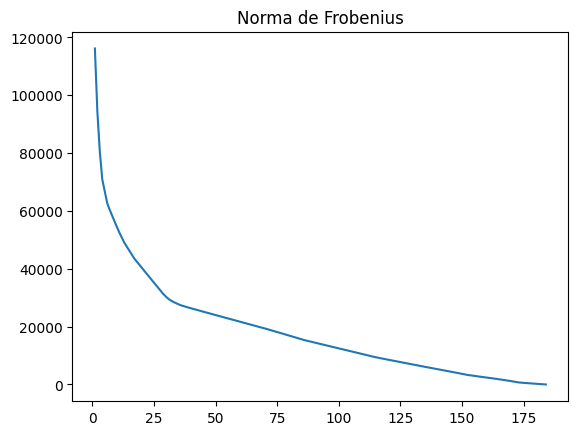

In [42]:
# ======================================================================================================
# NORMA DE FORBENIUS
# ======================================================================================================

def frobenius_norm(S):
    r = len(S)
    k = []
    erros = []

    for i in range(1, r + 1):
        descartado = S[i:]

        f = np.sqrt(np.sum(descartado ** 2))
        k.append(i)
        erros.append(f)

    return k, erros

def plot_frobenius(S):
    k, erros = frobenius_norm(S)
    plt.title("Norma de Frobenius")
    plt.plot(k, erros)
    plt.show()

plot_frobenius(S)

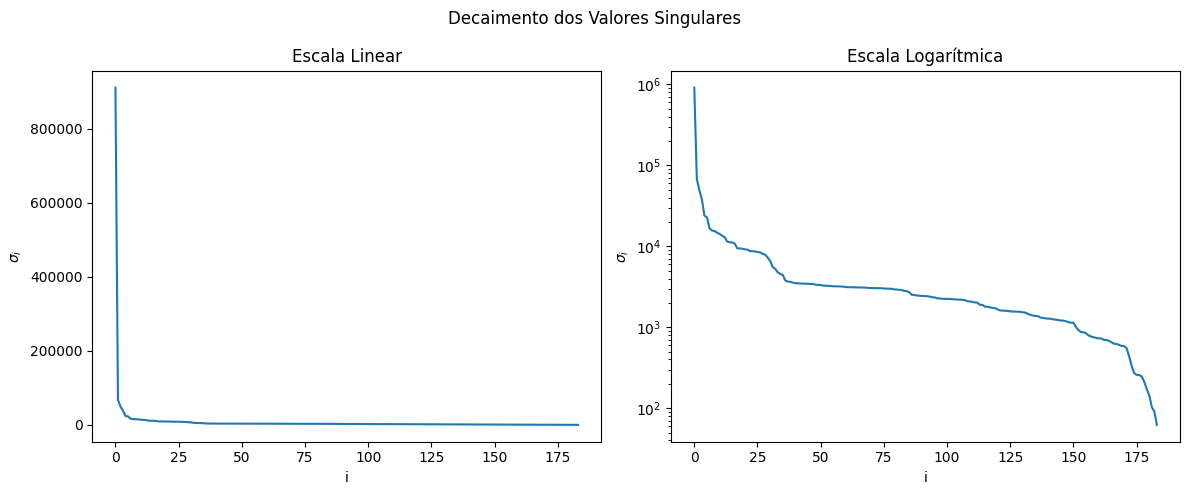

In [43]:
# ======================================================================================================
# DECAIMENTO DOS VALORES SINGULARES
# ======================================================================================================
def plotar_decaimento():

    figure, axes = plt.subplots(1, 2, figsize=(12, 5))

    plt.suptitle("Decaimento dos Valores Singulares")

    axes[0].set_title("Escala Linear")
    axes[0].plot(np.arange(len(S)), S)
    axes[0].set_xlabel("i")
    axes[0].set_ylabel(r"$\sigma_i$")


    axes[1].set_title("Escala Logarítmica")
    axes[1].set_yscale('log')
    axes[1].plot(np.arange(len(S)), S)
    axes[1].set_xlabel("i")
    axes[1].set_ylabel(r"$\sigma_i$")

    plt.tight_layout()
    plt.show()

plotar_decaimento()

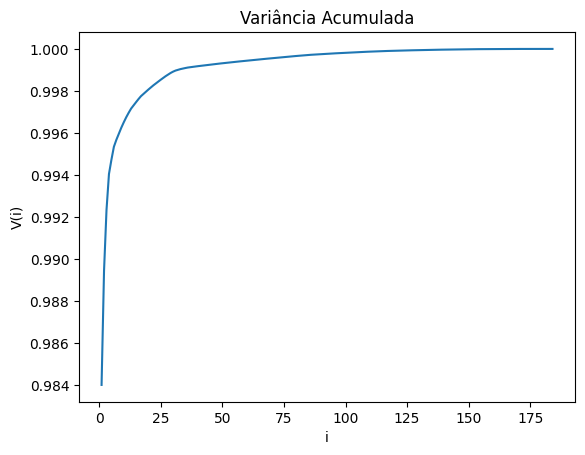

In [44]:
# ======================================================================================================
# VARIÂNCIA ACUMULADA
# ======================================================================================================

def plotar_variancia_acumulada():
    r = len(S)
    acc_var = []
    lista_k = []

    r_sum = np.sum(S ** 2)
    
    for i in range(1, r + 1):
        acc_var.append((np.sum(S[:i] ** 2)) / r_sum)
        lista_k.append(i)

    plt.title("Variância Acumulada")
    plt.xlabel("i")
    plt.ylabel("V(i)")
    plt.plot(lista_k, acc_var)
    plt.show()

plotar_variancia_acumulada()